In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import ShuffleSplit
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import Lasso
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn import svm

print("import done")

import done


In [2]:
df=pd.read_csv('pp.csv')
df.head(10)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.00
6,Super built-up Area,18-May,Old Airport Road,4 BHK,Jaades,2732,4.0,NaN,204.00
7,Super built-up Area,Ready To Move,Rajaji Nagar,4 BHK,Brway G,3300,4.0,NaN,600.00
8,Super built-up Area,Ready To Move,Marathahalli,3 BHK,NaN,1310,3.0,1.0,63.25
9,Plot Area,Ready To Move,Gandhi Bazar,6 Bedroom,NaN,1020,6.0,NaN,370.00


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [4]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [5]:
df['location'].unique()

array(['Electronic City Phase II', 'Chikka Tirupathi', 'Uttarahalli', ...,
       '12th cross srinivas nagar banshankari 3rd stage',
       'Havanur extension', 'Abshot Layout'], shape=(1306,), dtype=object)

In [6]:
df.groupby("area_type")["area_type"].agg('count')

area_type
Built-up  Area          2418
Carpet  Area              87
Plot  Area              2025
Super built-up  Area    8790
Name: area_type, dtype: int64

In [7]:
result = df.groupby("society")["price"].agg(["min", "max"])
result

,min,max
society,,
3Codeli,55.0,62.0
7 ise P,50.0,50.0
A idse,50.0,50.0
A rtsai,73.0,73.0
ACersd,115.0,115.0
...,...,...
Zonce E,77.5,120.0
Zostaa,60.0,65.0
i1ncyRe,50.0,50.0


In [8]:
df1=df.drop(["area_type","availability","society"], axis='columns')
df1

,location,size,total_sqft,bath,balcony,price
0,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Kothanur,2 BHK,1200,2.0,1.0,51.00
...,...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453,4.0,0.0,231.00
13316,Richards Town,4 BHK,3600,5.0,NaN,400.00
13317,Raja Rajeshwari Nagar,2 BHK,1141,2.0,1.0,60.00
13318,Padmanabhanagar,4 BHK,4689,4.0,1.0,488.00


In [9]:
df1['balcony']=df1['balcony'].fillna(df1['balcony'].mean())
df1

,location,size,total_sqft,bath,balcony,price
0,Electronic City Phase II,2 BHK,1056,2.0,1.000000,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,3.000000,120.00
2,Uttarahalli,3 BHK,1440,2.0,3.000000,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,1.000000,95.00
4,Kothanur,2 BHK,1200,2.0,1.000000,51.00
...,...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453,4.0,0.000000,231.00
13316,Richards Town,4 BHK,3600,5.0,1.584376,400.00
13317,Raja Rajeshwari Nagar,2 BHK,1141,2.0,1.000000,60.00
13318,Padmanabhanagar,4 BHK,4689,4.0,1.000000,488.00


In [10]:
df.groupby("bath")["bath"].agg('count')

bath
1.0      788
2.0     6908
3.0     3286
4.0     1226
5.0      524
6.0      273
7.0      102
8.0       64
9.0       43
10.0      13
11.0       3
12.0       7
13.0       3
14.0       1
15.0       1
16.0       2
18.0       1
27.0       1
40.0       1
Name: bath, dtype: int64

In [11]:
df1["bath"] = df1["bath"].fillna(df1["bath"].median())

In [12]:
df1

,location,size,total_sqft,bath,balcony,price
0,Electronic City Phase II,2 BHK,1056,2.0,1.000000,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,3.000000,120.00
2,Uttarahalli,3 BHK,1440,2.0,3.000000,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,1.000000,95.00
4,Kothanur,2 BHK,1200,2.0,1.000000,51.00
...,...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453,4.0,0.000000,231.00
13316,Richards Town,4 BHK,3600,5.0,1.584376,400.00
13317,Raja Rajeshwari Nagar,2 BHK,1141,2.0,1.000000,60.00
13318,Padmanabhanagar,4 BHK,4689,4.0,1.000000,488.00


In [13]:
df1['size']=df1['size'].str.extract(r"(\d+)").astype(float)

In [14]:
df1.isnull().sum()

location       1
size          16
total_sqft     0
bath           0
balcony        0
price          0
dtype: int64

In [15]:
df1['size'].unique()

array([ 2.,  4.,  3.,  6.,  1.,  8.,  7.,  5., 11.,  9., nan, 27., 10.,
       19., 16., 43., 14., 12., 13., 18.])

In [16]:
df1["size"] = df1["size"].fillna(df1["size"].median())

In [17]:
df1.total_sqft.unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      shape=(2117,), dtype=object)

In [18]:
def is_float(x):
    try:
        float(x)
        return True
    except:
        return False

In [19]:
#Show rows where total_sqft is not a valid float number
# ~ means not. 
#So, df[~ (valid float val)]

df1[~df1['total_sqft'].apply(is_float)].head(10)

,location,size,total_sqft,bath,balcony,price
30,Yelahanka,4.0,2100 - 2850,4.0,0.000000,186.000
56,Devanahalli,4.0,3010 - 3410,2.0,1.584376,192.000
81,Hennur Road,4.0,2957 - 3450,2.0,1.584376,224.500
122,Hebbal,4.0,3067 - 8156,4.0,0.000000,477.000
137,8th Phase JP Nagar,2.0,1042 - 1105,2.0,0.000000,54.005
165,Sarjapur,2.0,1145 - 1340,2.0,0.000000,43.490
188,KR Puram,2.0,1015 - 1540,2.0,0.000000,56.800
224,Devanahalli,3.0,1520 - 1740,2.0,1.584376,74.820
410,Kengeri,1.0,34.46Sq. Meter,1.0,0.000000,18.500
549,Hennur Road,2.0,1195 - 1440,2.0,0.000000,63.770


In [20]:
#this function will split and make a list of values and then explicitly 
#converting values in tokens into float and taking their average.
#if range then average , if string then float 

def sqft_float(x):
    tokens=x.split('-')
    if len(tokens)==2:
        return (float(tokens[0]) + float(tokens[1])) / 2
    try:
        return float(x)
    except:
        return None


In [21]:
sqft_float('34.46Sq. Meter34.46Sq. Meter')

In [22]:
sqft_float("2100 - 453335")

227717.5

In [23]:
df2=df1.copy()
df2['total_sqft']=df2['total_sqft'].apply(sqft_float)
df2.head(10)

,location,size,total_sqft,bath,balcony,price
0,Electronic City Phase II,2.0,1056.0,2.0,1.000000,39.07
1,Chikka Tirupathi,4.0,2600.0,5.0,3.000000,120.00
2,Uttarahalli,3.0,1440.0,2.0,3.000000,62.00
3,Lingadheeranahalli,3.0,1521.0,3.0,1.000000,95.00
4,Kothanur,2.0,1200.0,2.0,1.000000,51.00
5,Whitefield,2.0,1170.0,2.0,1.000000,38.00
6,Old Airport Road,4.0,2732.0,4.0,1.584376,204.00
7,Rajaji Nagar,4.0,3300.0,4.0,1.584376,600.00
8,Marathahalli,3.0,1310.0,3.0,1.000000,63.25
9,Gandhi Bazar,6.0,1020.0,6.0,1.584376,370.00


In [24]:
df2.loc[410] #used to see info at location in dataframe

location      Kengeri
size              1.0
total_sqft        NaN
bath              1.0
balcony           0.0
price            18.5
Name: 410, dtype: object

In [25]:
df2 = df2.dropna(subset=["total_sqft"]).copy()

df2["total_sqft"] = df2["total_sqft"].astype(int)

In [26]:
df2 = df2.dropna(subset=["location"])

In [27]:
df2.sample(10)

,location,size,total_sqft,bath,balcony,price
7990,Uttarahalli,3.0,1580,3.0,1.000000,60.00
8625,1st Phase JP Nagar,2.0,1200,2.0,1.584376,86.00
5718,Kodihalli,3.0,1620,3.0,2.000000,130.00
13146,Basavanapura,7.0,1800,5.0,3.000000,65.00
5910,Hegde Nagar,2.0,1179,2.0,2.000000,49.35
1195,Chokkanahalli,1.0,1200,1.0,1.000000,28.00
2610,Kalena Agrahara,2.0,1187,2.0,3.000000,52.00
6398,Bellandur,2.0,1281,2.0,2.000000,87.00
4842,Nandi Hills,4.0,5000,4.0,2.000000,290.00
7083,Doddabommasandra,3.0,646,2.0,1.000000,65.00


In [28]:
df2.isnull().sum()

location      0
size          0
total_sqft    0
bath          0
balcony       0
price         0
dtype: int64

In [29]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13273 entries, 0 to 13319
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13273 non-null  object 
 1   size        13273 non-null  float64
 2   total_sqft  13273 non-null  int64  
 3   bath        13273 non-null  float64
 4   balcony     13273 non-null  float64
 5   price       13273 non-null  float64
dtypes: float64(4), int64(1), object(1)
memory usage: 725.9+ KB


In [30]:
#Feature engineering : creating , cleaning , scaling columns for finding more information

df3=df2.copy()
df3["price_per_sqft"]=df3['price']*100000/df3['total_sqft']
df3.head()

,location,size,total_sqft,bath,balcony,price,price_per_sqft
0,Electronic City Phase II,2.0,1056,2.0,1.0,39.07,3699.810606
1,Chikka Tirupathi,4.0,2600,5.0,3.0,120.00,4615.384615
2,Uttarahalli,3.0,1440,2.0,3.0,62.00,4305.555556
3,Lingadheeranahalli,3.0,1521,3.0,1.0,95.00,6245.890861
4,Kothanur,2.0,1200,2.0,1.0,51.00,4250.000000


In [31]:
df3.location=df3.location.apply(lambda x: x.strip())
location_stats=df3.groupby('location')['location'].agg('count').sort_values(ascending=False)
location_stats

location
Whitefield               539
Sarjapur  Road           399
Electronic City          304
Kanakpura Road           271
Thanisandra              236
                        ... 
Kanakapura Main Road       1
1 Giri Nagar               1
Kanakapura Road,           1
Kanakapura main  Road      1
whitefiled                 1
Name: location, Length: 1288, dtype: int64

In [32]:
len(location_stats[location_stats<=10])

1048

In [33]:
LS_lessthan10=location_stats[location_stats<=10]
LS_lessthan10

location
Ganga Nagar              10
Thyagaraja Nagar         10
Sadashiva Nagar          10
Gunjur Palya             10
Dodsworth Layout         10
                         ..
Kanakapura Main Road      1
1 Giri Nagar              1
Kanakapura Road,          1
Kanakapura main  Road     1
whitefiled                1
Name: location, Length: 1048, dtype: int64

In [34]:
len(df3.location.unique())

1288

In [35]:
df3.location=df3.location.apply(lambda x:'other' if x in LS_lessthan10 else x)
len(df3.location.unique())

241

In [36]:
df3.head(10)

,location,size,total_sqft,bath,balcony,price,price_per_sqft
0,Electronic City Phase II,2.0,1056,2.0,1.000000,39.07,3699.810606
1,Chikka Tirupathi,4.0,2600,5.0,3.000000,120.00,4615.384615
2,Uttarahalli,3.0,1440,2.0,3.000000,62.00,4305.555556
3,Lingadheeranahalli,3.0,1521,3.0,1.000000,95.00,6245.890861
4,Kothanur,2.0,1200,2.0,1.000000,51.00,4250.000000
5,Whitefield,2.0,1170,2.0,1.000000,38.00,3247.863248
6,Old Airport Road,4.0,2732,4.0,1.584376,204.00,7467.057101
7,Rajaji Nagar,4.0,3300,4.0,1.584376,600.00,18181.818182
8,Marathahalli,3.0,1310,3.0,1.000000,63.25,4828.244275
9,other,6.0,1020,6.0,1.584376,370.00,36274.509804


# Now to remove the outliers like bedrooms vs total sqft and no. of bathrooms vs bedroom 

In [37]:
df3['bhk']=df3['size']
df3=df3.drop(["size"], axis='columns')

In [38]:
df3

,location,total_sqft,bath,balcony,price,price_per_sqft,bhk
0,Electronic City Phase II,1056,2.0,1.000000,39.07,3699.810606,2.0
1,Chikka Tirupathi,2600,5.0,3.000000,120.00,4615.384615,4.0
2,Uttarahalli,1440,2.0,3.000000,62.00,4305.555556,3.0
3,Lingadheeranahalli,1521,3.0,1.000000,95.00,6245.890861,3.0
4,Kothanur,1200,2.0,1.000000,51.00,4250.000000,2.0
...,...,...,...,...,...,...,...
13315,Whitefield,3453,4.0,0.000000,231.00,6689.834926,5.0
13316,other,3600,5.0,1.584376,400.00,11111.111111,4.0
13317,Raja Rajeshwari Nagar,1141,2.0,1.000000,60.00,5258.545136,2.0
13318,Padmanabhanagar,4689,4.0,1.000000,488.00,10407.336319,4.0


In [39]:
#likely bedroom area is more than 300sqft
df3[df3.total_sqft/df3.bhk<300].head()

,location,total_sqft,bath,balcony,price,price_per_sqft,bhk
9,other,1020,6.0,1.584376,370.0,36274.509804,6.0
45,HSR Layout,600,9.0,1.584376,200.0,33333.333333,8.0
58,Murugeshpalya,1407,4.0,1.000000,150.0,10660.980810,6.0
68,Devarachikkanahalli,1350,7.0,0.000000,85.0,6296.296296,8.0
70,other,500,3.0,2.000000,100.0,20000.000000,3.0


In [40]:
df3.shape

(13273, 7)

In [41]:
#made new df where it kept rows where total_sqft/bhk is not less than 300
df4=df3[~(df3.total_sqft/df3.bhk<300)]
df4.shape

(12529, 7)

In [42]:
df4.price_per_sqft.describe()

count     12529.000000
mean       6304.080496
std        4162.399432
min         267.829813
25%        4210.526316
50%        5294.117647
75%        6916.666667
max      176470.588235
Name: price_per_sqft, dtype: float64

In [43]:
# Python automatically unpacks two things from groupby():(group_name, grouped_dataframe)
# key gets group name , subdf gets a dataframe

def remove_pps_outliers(df):
    df_out = pd.DataFrame()

    for key, subdf in df.groupby('location'):

        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)

        reduced_df = subdf[
            (subdf.price_per_sqft > (m - st)) &
            (subdf.price_per_sqft <= (m + st))
        ]

        df_out = pd.concat([df_out, reduced_df], ignore_index=True)

    return df_out

df5=remove_pps_outliers(df4)
df5.shape

(10301, 7)

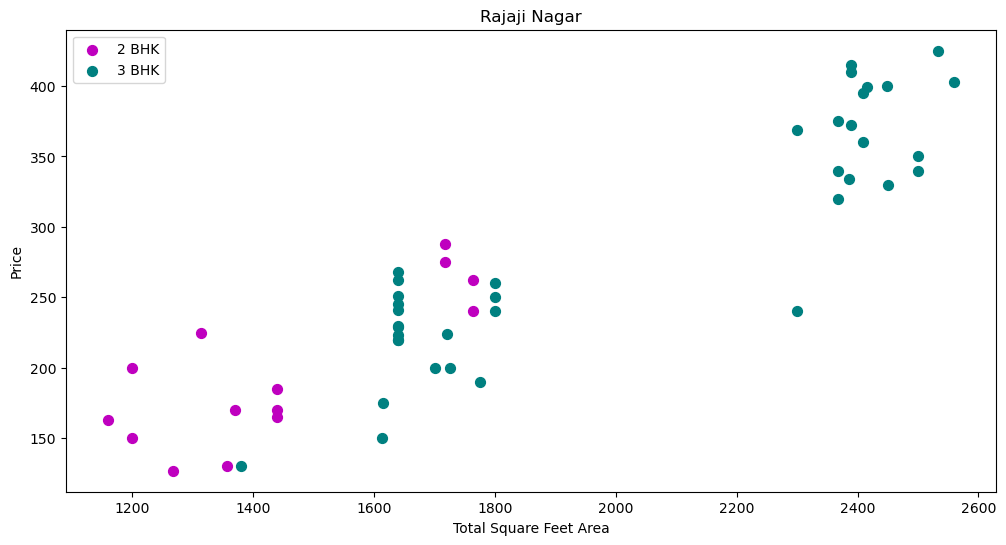

In [44]:
#there are 2bhk house price more than 3bhk ,visualizing that


def plot_scatter_chart(df,location):
    bhk2=df[(df.location==location)&(df.bhk==2)]
    bhk3=df[(df.location==location)&(df.bhk==3)]
    matplotlib.rcParams['figure.figsize'] = (12,6) #matplotlib.rcParams['figure.figsize'] = (12,6)
    plt.scatter(bhk2.total_sqft,bhk2.price,color='m',label='2 BHK' ,s=50)
    plt.scatter(bhk3.total_sqft,bhk3.price ,color='teal',label='3 BHK' ,s=50)
    plt.xlabel("Total Square Feet Area")
    plt.ylabel("Price")
    plt.title(location)
    plt.legend()
plot_scatter_chart(df5,"Rajaji Nagar")
    

In [45]:
def remove_bhk_outliers(df):
    exclude_indices = np.array([])
    for location, location_df in df.groupby('location'):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk] = {
                'mean': np.mean(bhk_df.price_per_sqft),
                'std': np.std(bhk_df.price_per_sqft),
                'count': bhk_df.shape[0]
            }
        for bhk, bhk_df in location_df.groupby('bhk'):
            stats = bhk_stats.get(bhk-1)
            if stats and stats['count']>5:
                exclude_indices = np.append(exclude_indices, bhk_df[bhk_df.price_per_sqft<(stats['mean'])].index.values)
    return df.drop(exclude_indices,axis='index')
df6 = remove_bhk_outliers(df5)
df6.shape

(7348, 7)

# DRY RUN
 Sample Data

 idx | location       | bhk | price_per_sqft \
 0     | Rajaji Nagar   |    1   | 4000\
 1     | Rajaji Nagar   | 2   | 5000\
 2     | Rajaji Nagar   | 2   | 5200\
 3     | Rajaji Nagar   | 2   | 5100\
 4     | Rajaji Nagar   | 2   | 5300\
 5     | Rajaji Nagar   | 2   | 4900\
 6     | Rajaji Nagar   | 2   | 5050\
 7     | Rajaji Nagar   | 3   | 4800\
 8     | Rajaji Nagar   | 3   | 7000


def remove_bhk_outliers(df):

    # Step 1: Create empty array to store indexes of outliers
    exclude_indices = np.array([])

    # Step 2: Group dataframe by location
    for location, location_df in df.groupby('location'):

        # For Rajaji Nagar:
        # location = "Rajaji Nagar"
        # location_df contains only Rajaji Nagar rows

        bhk_stats = {}

        # Step 3: Group location data by BHK
        for bhk, bhk_df in location_df.groupby('bhk'):

            # 1 BHK → [4000]
            # 2 BHK → [5000,5200,5100,5300,4900,5050]
            # 3 BHK → [4800,7000]

            bhk_stats[bhk] = {

                # Mean price_per_sqft
                'mean': np.mean(bhk_df.price_per_sqft),

                # Standard deviation
                'std': np.std(bhk_df.price_per_sqft),

                # Number of rows
                'count': bhk_df.shape[0]
            }

        # After loop:
        # bhk_stats becomes:

        # {
        #   1: {'mean':4000, 'count':1},
        #   2: {'mean':5091.6, 'count':6},
        #   3: {'mean':5900, 'count':2}
        # }

        # Step 4: Loop again through each BHK
        for bhk, bhk_df in location_df.groupby('bhk'):

            # Get previous BHK statistics
            stats = bhk_stats.get(bhk-1)

            # Example:
            # if current bhk = 3
            # then bhk-1 = 2
            # stats = {'mean':5091.6,'count':6}

            # Check:
            # 1. previous bhk exists
            # 2. enough samples exist
            if stats and stats['count'] > 5:

                # Find houses whose price_per_sqft
                # is less than previous BHK mean

                # For 3 BHK:
                # compare against 2 BHK mean = 5091.6

                # 4800 < 5091.6 → True
                # 7000 < 5091.6 → False

                exclude_indices = np.append(

                    exclude_indices,

                    bhk_df[
                        bhk_df.price_per_sqft < (stats['mean'])
                    ].index.values
                )

                # Row index 7 gets added

    # exclude_indices = [7]

    # Step 5: Remove outlier rows
    return df.drop(exclude_indices, axis='index')


# Final result
df8 = remove_bhk_outliers(df7)

 Row with:
 bhk = 3
 price_per_sqft = 4800
 gets removed


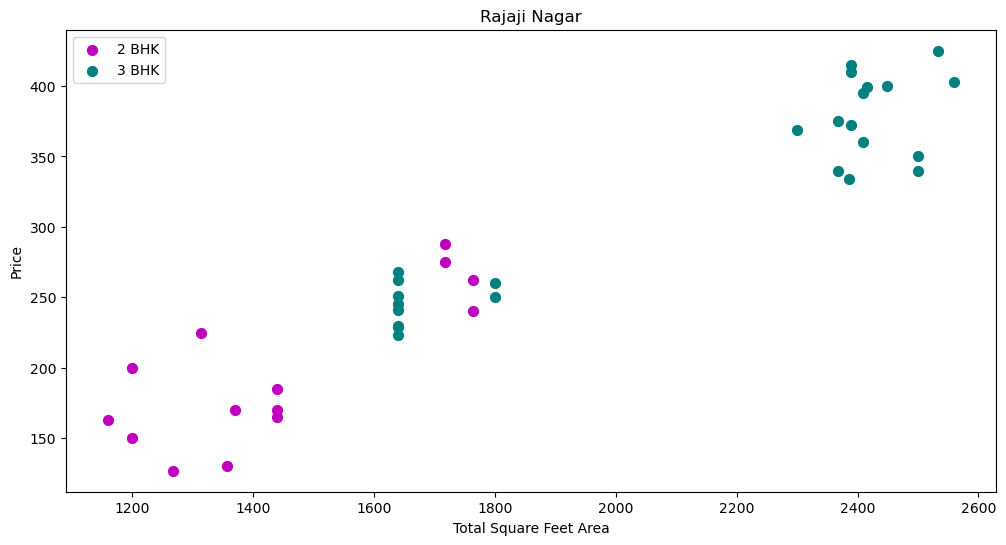

In [46]:

plot_scatter_chart(df6,"Rajaji Nagar")

Text(0, 0.5, 'Count')

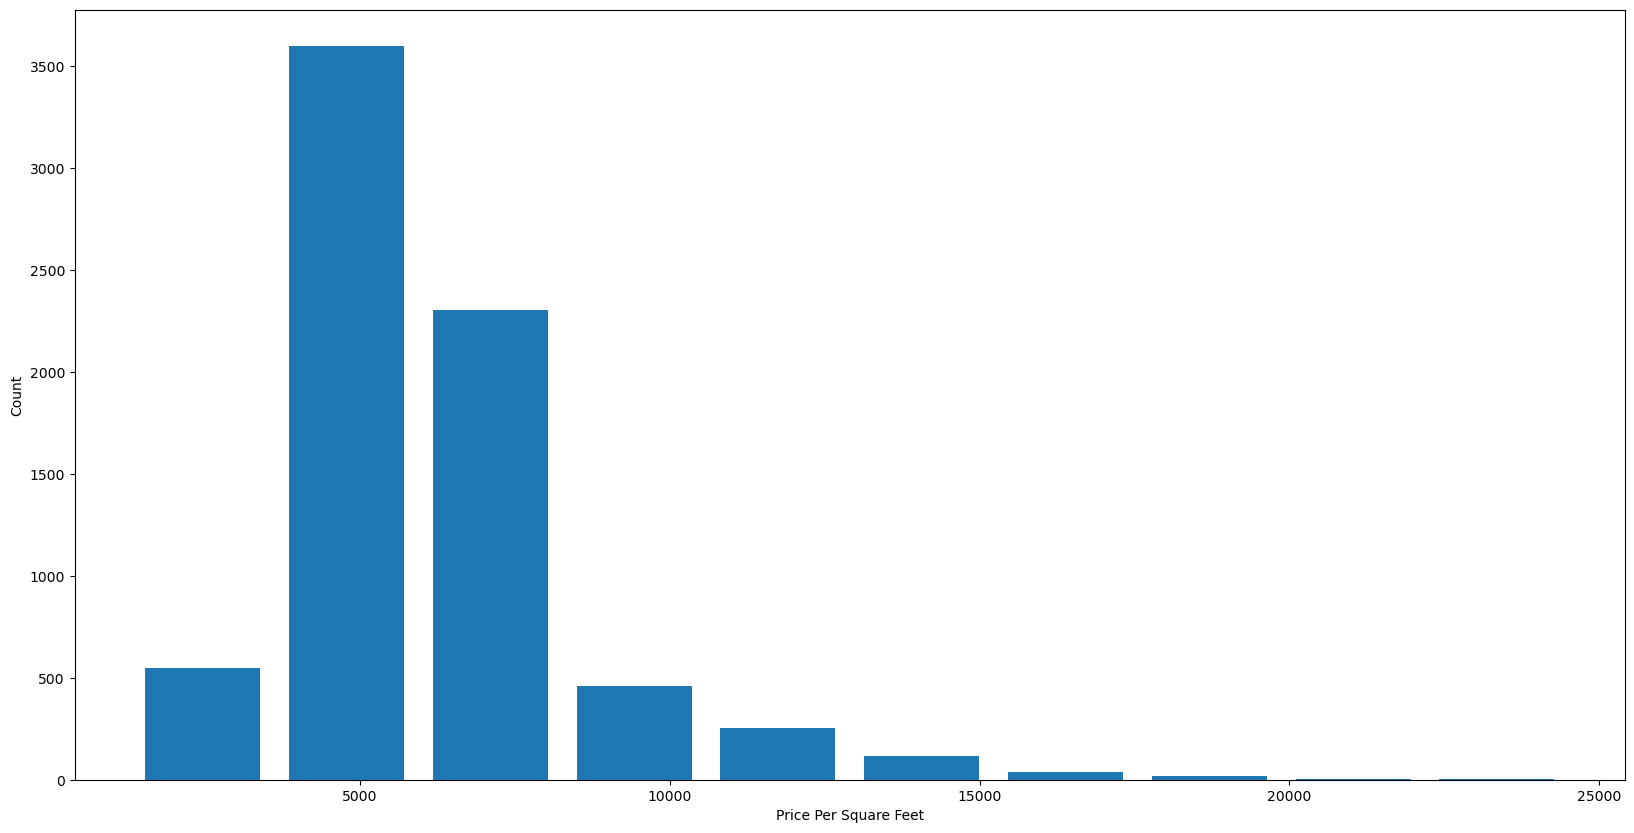

In [47]:
import matplotlib
matplotlib.rcParams["figure.figsize"] = (20,10)
plt.hist(df6.price_per_sqft,rwidth=0.8)
plt.xlabel("Price Per Square Feet")
plt.ylabel("Count")

In [48]:
df6.bath.unique()

array([ 4.,  3.,  2.,  5.,  8.,  1.,  6.,  7.,  9., 12., 16., 13.])

Text(0, 0.5, 'Count')

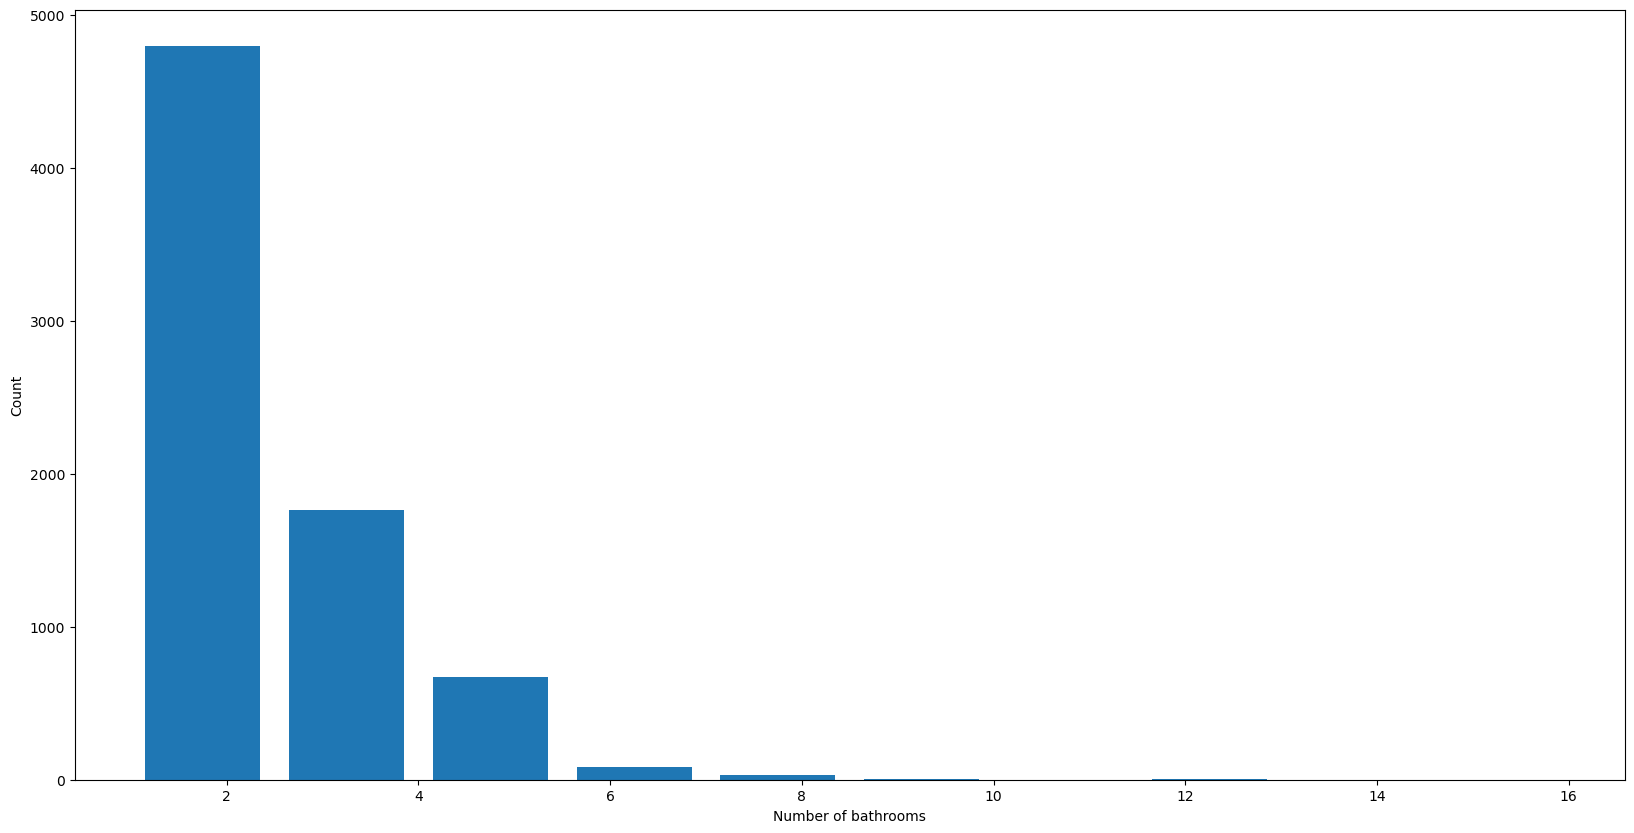

In [49]:
plt.hist(df6.bath,rwidth=0.8)
plt.xlabel("Number of bathrooms")
plt.ylabel("Count")

In [57]:
df7=df6[df6.bath<df6.bhk+2]

In [58]:
df7.shape

(7269, 7)

# Bath Outliers removed

In [60]:
df7[df7.bath>df7.bhk+2]

,location,total_sqft,bath,balcony,price,price_per_sqft,bhk


# Model Building

In [61]:
df8=df7.drop(['price_per_sqft'], axis='columns')
df8.head()

,location,total_sqft,bath,balcony,price,bhk
0,1st Block Jayanagar,2850,4.0,1.0,428.0,4.0
1,1st Block Jayanagar,1630,3.0,2.0,194.0,3.0
2,1st Block Jayanagar,1875,2.0,3.0,235.0,3.0
3,1st Block Jayanagar,1200,2.0,0.0,130.0,3.0
4,1st Block Jayanagar,1235,2.0,2.0,148.0,2.0


In [156]:
dummies = pd.get_dummies(df8['location'],dtype=int)
dummies.head()

,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,9th Phase JP Nagar,...,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur,other
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [155]:
df9=pd.concat([df8,dummies.drop('other',axis='columns')],axis='columns')
df9.head()

,location,total_sqft,bath,balcony,price,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,1st Block Jayanagar,2850,4.0,1.0,428.0,4.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1st Block Jayanagar,1630,3.0,2.0,194.0,3.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1st Block Jayanagar,1875,2.0,3.0,235.0,3.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1st Block Jayanagar,1200,2.0,0.0,130.0,3.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1st Block Jayanagar,1235,2.0,2.0,148.0,2.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [93]:
df9=df9.drop('location',axis='columns')

In [94]:
df9.shape

(7269, 245)

In [95]:
X=df9.drop('price',axis='columns')
y=df9.price

In [162]:
X.head(20)

,total_sqft,bath,balcony,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,2850,4.0,1.000000,4.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1630,3.0,2.000000,3.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1875,2.0,3.000000,3.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1200,2.0,0.000000,3.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1235,2.0,2.000000,2.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,2750,4.0,0.000000,4.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,2450,4.0,2.000000,4.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,1875,3.0,1.000000,3.0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,1500,5.0,1.584376,5.0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10,2065,4.0,1.000000,3.0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [97]:
y.head()

0    428.0
1    194.0
2    235.0
3    130.0
4    148.0
Name: price, dtype: float64

In [98]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=10)

In [99]:
lr_model=LinearRegression()

In [100]:
lr_model.fit(X_train,y_train)
lr_model.score(X_test,y_test)

0.8720492414710798

In [104]:
cv=ShuffleSplit(n_splits=5 , test_size=0.2 , random_state=0)
cross_val_score(LinearRegression(),X,y,cv=cv)

array([0.82281352, 0.8439456 , 0.8682576 , 0.78357576, 0.79984108])

In [127]:
def find_best_model(X,y):
    model_params={
        'Lasso':{
            'model':Lasso(),
            'params':{
                'alpha':[1,2],
                'selection':['random','cyclic']
            }
        },
        'decision_tree':{
            'model':DecisionTreeRegressor(),
            'params':{
                'criterion':['squared_error','friedman_mse'],
                'splitter':['best','random']
            }
        },
        'random_forest':{
            'model':RandomForestRegressor(),
            'params':{
                'n_estimators':[1,10,50,100]
            }
        },
        'Linear_regression':{
            'model':LinearRegression(),
            'params':{
                'fit_intercept':[True,False]
            }
        }
    }

    res=[]

    cv=ShuffleSplit(n_splits=5 , test_size=0.2 , random_state=0)
    for m_name,mp in model_params.items():
        clf = GridSearchCV(mp['model'],
                           mp['params'],
                           cv=cv,
                           return_train_score=False
        )
        clf.fit(X_train, y_train)
        res.append({
        "model":m_name,
        'best_score':clf.best_score_,
        'best_param':clf.best_params_
        })

    return pd.DataFrame(res,columns=['model', 'best_score', 'best_param']).sort_values(by='best_score',ascending=False).reset_index(drop=True)


In [128]:
find_best_model(X,y)

,model,best_score,best_param
0,Linear_regression,0.842567,{'fit_intercept': False}
1,random_forest,0.790649,{'n_estimators': 10}
2,Lasso,0.709652,"{'alpha': 1, 'selection': 'cyclic'}"
3,decision_tree,0.702341,"{'criterion': 'squared_error', 'splitter': 'ra..."


In [163]:
def predict_price(location, sqft, bath, bhk, balcony):

    loc_index = np.where(X.columns == location)[0][0]

    x = np.zeros(len(X.columns))

    x[X.columns.get_loc('total_sqft')] = sqft
    x[X.columns.get_loc('bath')] = bath
    x[X.columns.get_loc('balcony')] = balcony
    x[X.columns.get_loc('bhk')] = bhk

    if loc_index >= 0:
        x[loc_index] = 1
        
    return lr_model.predict(
    pd.DataFrame([x], columns=X.columns))[0]
    
print("function successfull") 

function successfull


In [164]:
predict_price('1st Block Jayanagar',1630,3,1,3)

np.float64(260.4916860512725)

np.where(X.columns == 'Cooke Town')\
returns tuple ---> (array([4]),)\
After first [0] ---> array([4])\
After second [0] ---> 4
\
Simple Analogy\
Think of it like:\
\
(\
   [4]\
)
\
First [0]:\
gets list\
Second [0]:\
gets actual number

# DRY RUN 
location = 1st Block Jayanagar\
loc_index=5\
x=[000000....]\
x[0] = sqft \
x[1] = bath \
x[2] = balcony\
x[3] = bhk\
Now 0,1,2,3 are reserved then\
then 5>0 [TRUE]\
x[5]=1 and other columns remain 0


In [129]:
len(X.columns)

244

In [135]:
X.shape

(7269, 244)

In [ ]:
import pickle
with open('banglore_home_prices_model.pickle','wb') as f:
    pickle.dump(lr_model,f)